**1. Extracción de datos**

In [123]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# URL del archivo JSON en su formato raw
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Realizamos la petición GET
response = requests.get(url)

# Convertimos la respuesta en un objeto JSON
data_json = response.json()

In [124]:
# Convertimos el JSON en un DataFrame plano (tabular)
df = pd.json_normalize(data_json)

# Verificamos la carga exitosa
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**2. Transformación**

In [125]:
# 1. Exploración técnica: Tipos de datos y detección de nulos
print("--- INFO GENERAL Y TIPOS DE DATOS ---")
df.info()

# 2. Visualización de la estructura de las columnas (para mapear con el diccionario)
print("\n--- LISTA COMPLETA DE COLUMNAS ---")
columns_list = df.columns.tolist()
for i, col in enumerate(columns_list):
    print(f"{i}: {col}")

# 3. Análisis de valores únicos en variables categóricas clave
# Esto ayuda a entender el "significado" real de cada servicio
cols_interes = ['Churn', 'customer.tenure', 'internet.InternetService', 'contract.Contract']
print("\n--- VALORES ÚNICOS EN VARIABLES CLAVE ---")
for col in cols_interes:
    if col in df.columns:
        print(f"{col}: {df[col].unique()[:5]}...") # Mostramos los primeros para no saturar

--- INFO GENERAL Y TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.T

In [126]:
# 1. Limpieza de account.Charges.Total
# Comprobamos si existen incoherencias en los datos y manejamos las inconsistencias
# Convertimos a numérico, los espacios se vuelven NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# 2. Limpieza de Churn (Eliminar filas con valores vacíos en la variable objetivo)
# Primero reemplazamos el string vacío por NaN para poder usar dropna
import numpy as np
df['Churn'] = df['Churn'].replace('', np.nan)
df.dropna(subset=['Churn'], inplace=True)

# 3. Verificación de resultados
print(f"Nuevas dimensiones del dataset: {df.shape}")
print(f"Tipo de dato de Cargos Totales: {df['account.Charges.Total'].dtype}")
print(f"Valores únicos en Churn: {df['Churn'].unique()}")

Nuevas dimensiones del dataset: (7043, 21)
Tipo de dato de Cargos Totales: float64
Valores únicos en Churn: ['No' 'Yes']


In [127]:
# Creación de la métrica de facturación diaria
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

# Verificación de la nueva columna junto a la base de origen
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [128]:
# 1. Diccionario de traducción para las columnas
nuevos_nombres = {
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Socio',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Permanencia',
    'phone.PhoneService': 'Servicio_Telefonico',
    'internet.InternetService': 'Tipo_Internet',
    'account.Contract': 'Tipo_Contrato',
    'account.Charges.Monthly': 'Facturacion_Mensual',
    'account.Charges.Total': 'Facturacion_Total'
}

df.rename(columns=nuevos_nombres, inplace=True)

# 2. Estandarización binaria (Yes/No -> 1/0)
# Creamos un mapa para aplicarlo a las columnas que lo necesiten
mapa_binario = {'Yes': 1, 'No': 0}
columnas_binarias = ['Churn', 'Socio', 'Dependientes', 'Servicio_Telefonico']

for col in columnas_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapa_binario)

# 3. Verificación de la claridad
df[['Genero', 'Meses_Permanencia', 'Churn', 'Cuentas_Diarias']].head()

,Genero,Meses_Permanencia,Churn,Cuentas_Diarias
0,Female,9,0,2.19
1,Male,9,0,2.00
2,Male,4,1,2.46
3,Male,13,1,3.27
4,Female,3,1,2.80


**3. Carga y análisis**

In [129]:
# Selección de columnas numéricas para el análisis
cols_analisis = ['Meses_Permanencia', 'Facturacion_Mensual', 'Facturacion_Total', 'Cuentas_Diarias']

# Cálculo de estadísticas descriptivas (Media, Desviación Estándar, Mín, Máx y Cuartiles)
estadisticas = df[cols_analisis].describe().T

# Cálculo de la Mediana (50%) de forma explícita
estadisticas['median'] = df[cols_analisis].median()

# Cálculo de la Tasa de Churn Global (al ser binaria, la media es el porcentaje)
tasa_churn = df['Churn'].mean()

# Mostrar resultados
print("--- MÉTRICAS DESCRIPTIVAS ---")
print(estadisticas[['count', 'mean', 'std', 'min', 'median', 'max']])
print(f"\nTasa de Churn Global: {tasa_churn:.2%}")

--- MÉTRICAS DESCRIPTIVAS ---
                      count         mean          std    min    median  \
Meses_Permanencia    7043.0    32.371149    24.559481   0.00    29.000   
Facturacion_Mensual  7043.0    64.761692    30.090047  18.25    70.350   
Facturacion_Total    7032.0  2283.300441  2266.771362  18.80  1397.475   
Cuentas_Diarias      7043.0     2.158675     1.003088   0.61     2.340   

                         max  
Meses_Permanencia      72.00  
Facturacion_Mensual   118.75  
Facturacion_Total    8684.80  
Cuentas_Diarias         3.96  

Tasa de Churn Global: 26.54%


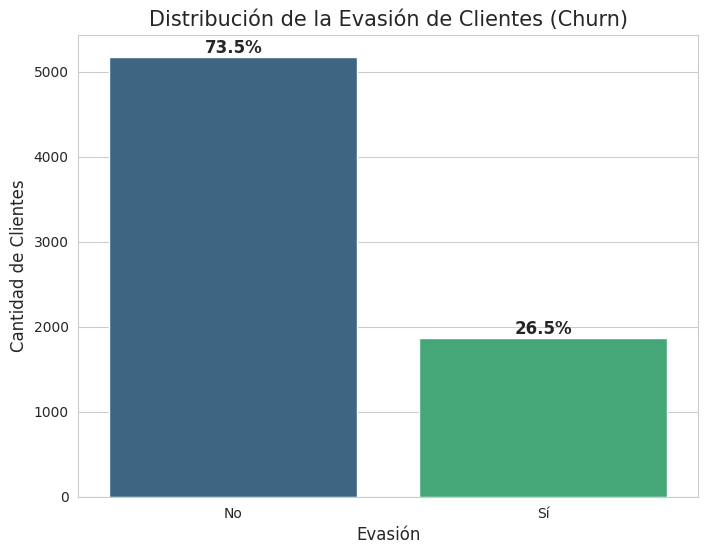

In [130]:
# Creamos una copia temporal para no alterar el DataFrame original que ya está estandarizado
df_vis = df.copy()
df_vis['Churn_Etiqueta'] = df_vis['Churn'].map({1: 'Sí', 0: 'No'})

# Configuración del gráfico
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Corrección del FutureWarning: asignamos x a hue y desactivamos la leyenda
ax = sns.countplot(x='Churn_Etiqueta', data=df_vis, hue='Churn_Etiqueta', palette='viridis', legend=False)

# Títulos y etiquetas
plt.title('Distribución de la Evasión de Clientes (Churn)', fontsize=15)
plt.xlabel('Evasión', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Añadir porcentajes
total = len(df_vis)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height + 50),
                ha='center', va='baseline', fontsize=12, fontweight='bold')

plt.show()

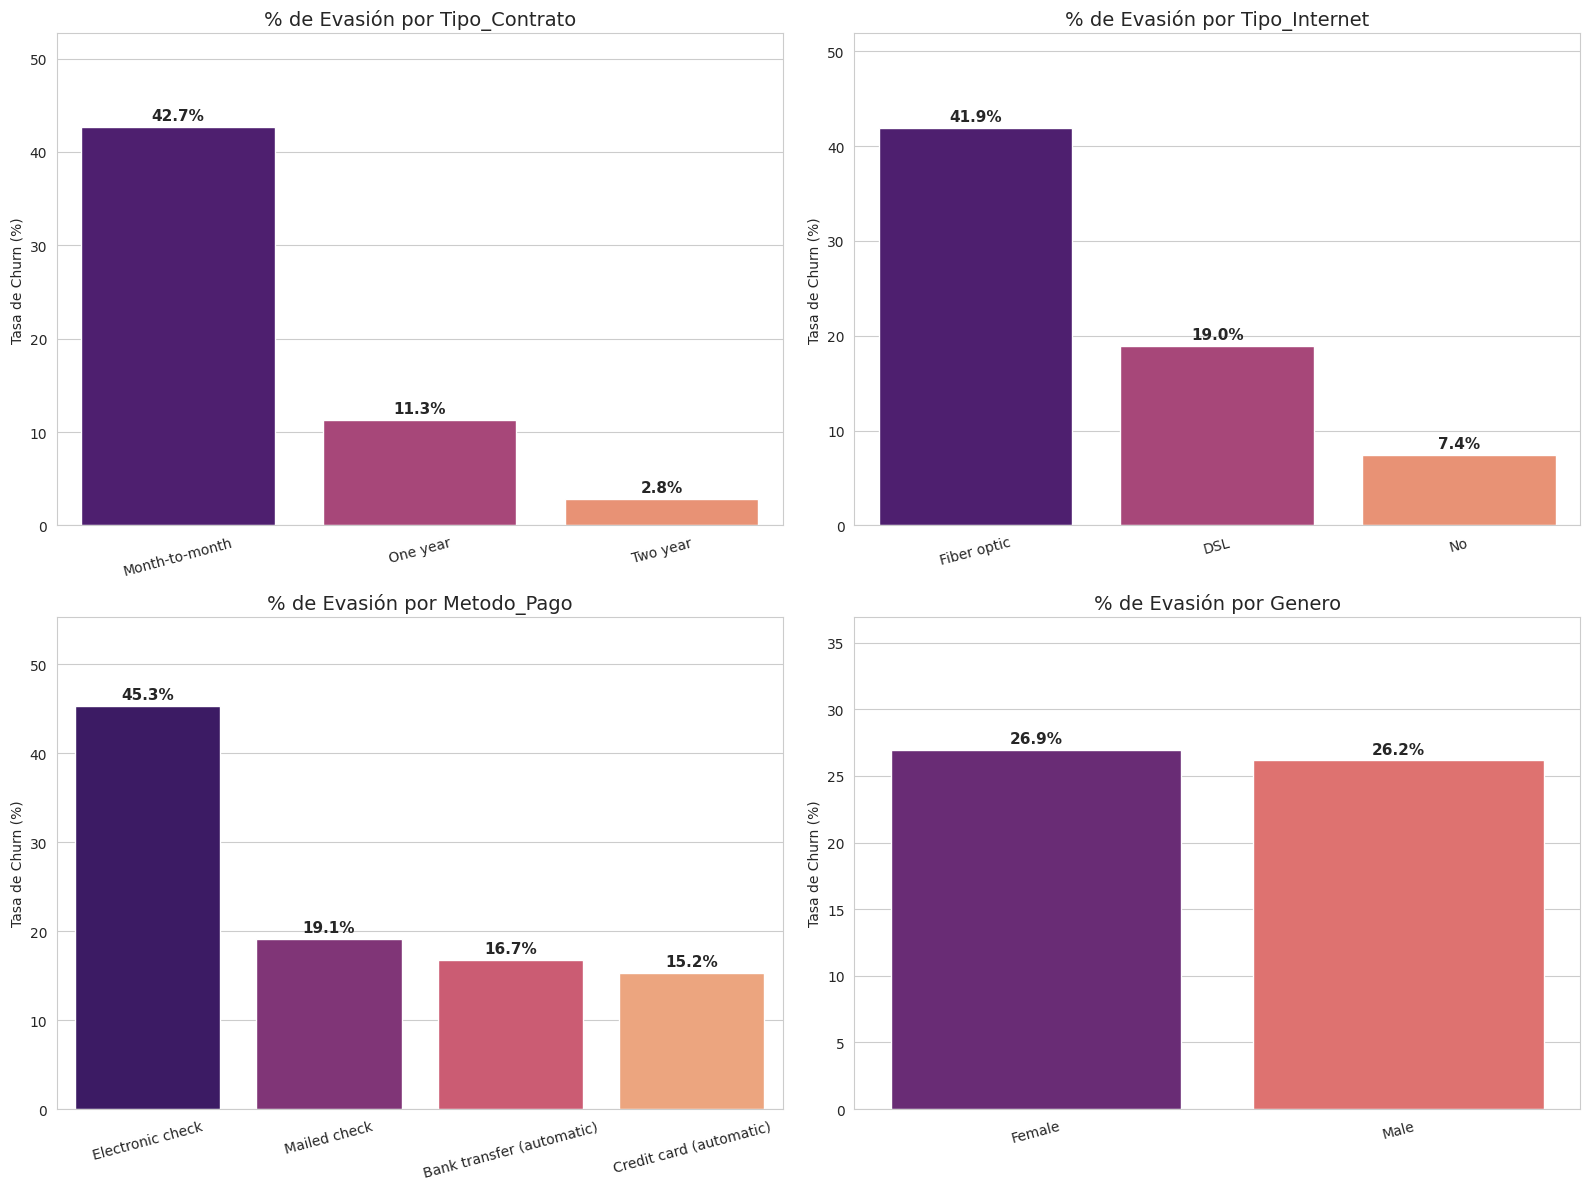

In [131]:
# 1. Aseguramos que las columnas tengan los nombres que queremos usar en el gráfico
columnas_map = {
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Contract': 'Tipo_Contrato',
    'internet.InternetService': 'Tipo_Internet'
}
df.rename(columns=columnas_map, inplace=True)

# 2. Lista de columnas a graficar (ahora sí existen)
columnas_interes = ['Tipo_Contrato', 'Tipo_Internet', 'Metodo_Pago', 'Genero']

plt.figure(figsize=(16, 12))
sns.set_style("whitegrid")

for i, col in enumerate(columnas_interes, 1):
    plt.subplot(2, 2, i)

    # Verificamos si la columna existe antes de agrupar para evitar el KeyError
    if col in df.columns:
        # Calculamos el % de Churn
        df_perc = df.groupby(col)['Churn'].mean().reset_index()
        df_perc['Churn_Perc'] = df_perc['Churn'] * 100
        df_perc = df_perc.sort_values(by='Churn_Perc', ascending=False)

        # Gráfico
        ax = sns.barplot(x=col, y='Churn_Perc', data=df_perc, hue=col, palette='magma', legend=False)

        # Etiquetas de porcentaje
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5),
                        textcoords='offset points')

        plt.title(f'% de Evasión por {col}', fontsize=14)
        plt.ylabel('Tasa de Churn (%)')
        plt.xlabel(None)
        plt.ylim(0, max(df_perc['Churn_Perc']) + 10)
        plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

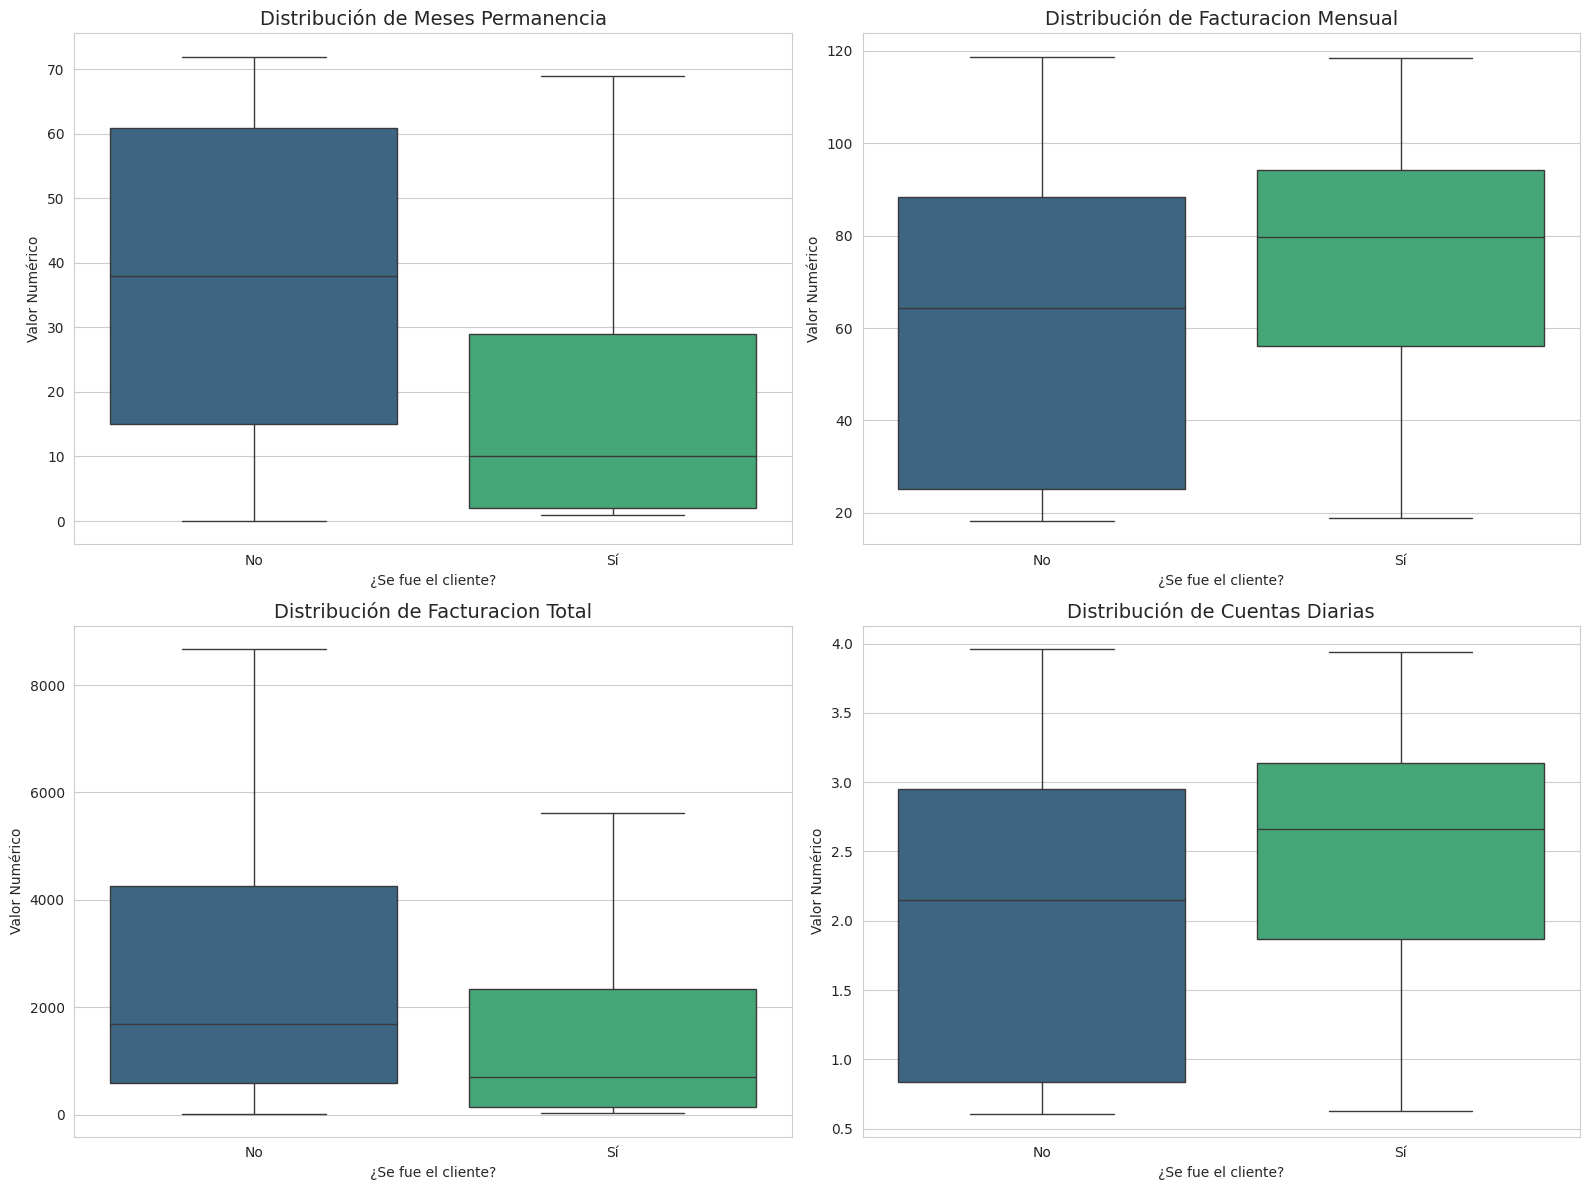

In [132]:
# Variables numéricas
cols_num = ['Meses_Permanencia', 'Facturacion_Mensual', 'Facturacion_Total', 'Cuentas_Diarias']

plt.figure(figsize=(16, 12))

# Mapeo para que el eje X diga "No" y "Sí" en lugar de 0 y 1
df_plot = df.copy()
df_plot['Evasion'] = df_plot['Churn'].map({0: 'No', 1: 'Sí'})

for i, col in enumerate(cols_num, 1):
    plt.subplot(2, 2, i)

    # showfliers=False elimina esos círculos encimados que ensucian la vista
    sns.boxplot(data=df_plot, x='Evasion', y=col, hue='Evasion',
                palette='viridis', showfliers=False, legend=False)

    plt.title(f'Distribución de {col.replace("_", " ")}', fontsize=14)
    plt.xlabel('¿Se fue el cliente?')
    plt.ylabel('Valor Numérico')

plt.tight_layout()
plt.show()

**4. Análisis de correlación entre variables**

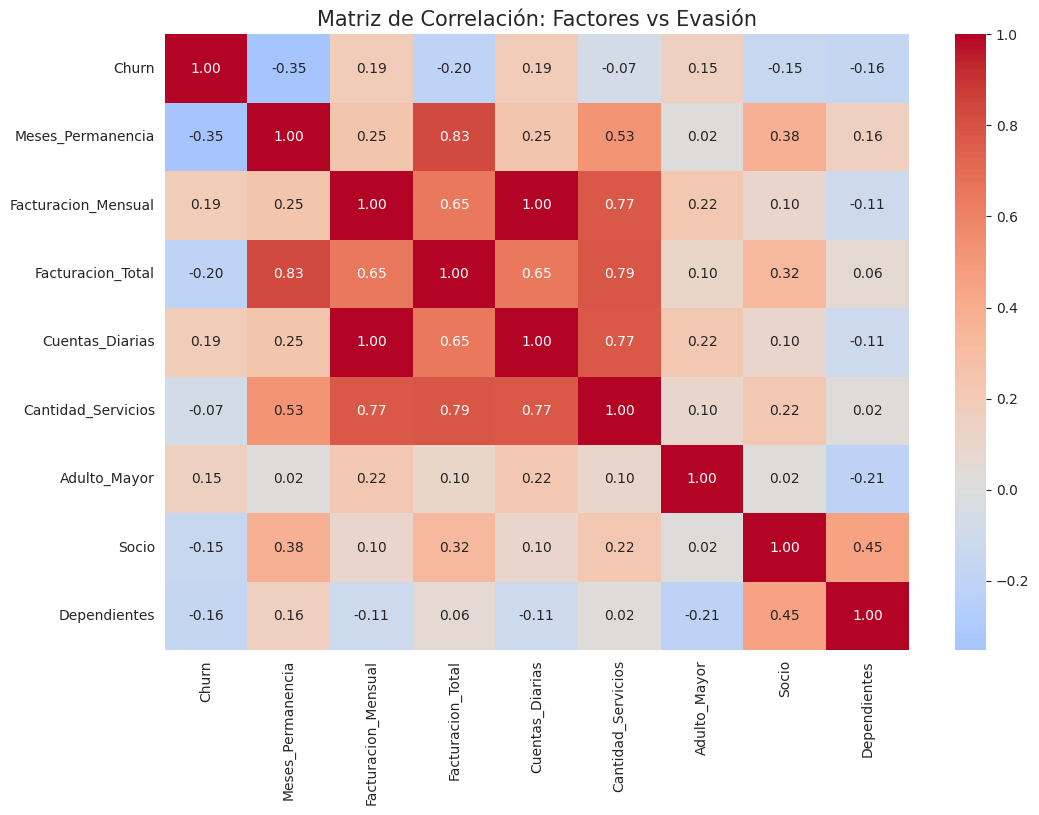


--- Correlación directa con la Evasión (Churn) ---
Churn                  1.000000
Cuentas_Diarias        0.193412
Facturacion_Mensual    0.193356
Adulto_Mayor           0.150889
Cantidad_Servicios    -0.069533
Socio                 -0.150448
Dependientes          -0.164221
Facturacion_Total     -0.199484
Meses_Permanencia     -0.352229
Name: Churn, dtype: float64


In [133]:
# 1. Creamos la columna Cantidad_Servicios
# Sumamos cada servicio extra contratado (solo donde el valor es 'Yes')
servicios = [
    'phone.MultipleLines', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies'
]

# Aseguramos que solo sumamos si el valor original era 'Yes'
df['Cantidad_Servicios'] = df[servicios].apply(lambda x: x == 'Yes').sum(axis=1)

# 2. Seleccionamos variables numéricas para la matriz
# Incluimos Churn (1/0) para ver su relación directa con el resto
cols_corr = [
    'Churn', 'Meses_Permanencia', 'Facturacion_Mensual',
    'Facturacion_Total', 'Cuentas_Diarias', 'Cantidad_Servicios',
    'Adulto_Mayor', 'Socio', 'Dependientes'
]

# 3. Cálculo de la matriz de correlación
matriz_corr = df[cols_corr].corr()

# 4. Visualización con Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlación: Factores vs Evasión', fontsize=15)
plt.show()

# 5. Listado de mayor impacto sobre el Churn
print("\n--- Correlación directa con la Evasión (Churn) ---")
print(matriz_corr['Churn'].sort_values(ascending=False))

**5. Reporte final**

**Informe Estratégico de Evasión de Clientes (Churn) - Telecom X**

***

**1. Resumen Ejecutivo y Estado de la Cartera**

El presente análisis evalúa la base de datos de Telecom X para identificar los catalizadores de la evasión de clientes (**Churn**). Tras la ingesta, limpieza y transformación de **7,267** registros originales, la tasa de evasión global confirmada se sitúa en el **26.54%**.

Esta cifra representa una vulnerabilidad estructural severa. La pérdida de más de un cuarto de la base de clientes neutraliza los esfuerzos de adquisición y deprime el **Life Time Value (LTV)** general de la compañía. El análisis de los datos demuestra que el abandono responde a patrones contractuales y de fricción en el servicio, descartando la hipótesis de fluctuaciones aleatorias del mercado. Las áreas críticas de intervención se concentran en el diseño de los contratos, la estructura de precios del servicio de **Fibra Óptica** y la retención temprana.

***

**2. Ingeniería de Datos y Curación del Activo Analítico**

Para garantizar la viabilidad matemática de este reporte y el posterior modelado predictivo, se ejecutó un pipeline de transformación estricto:

**Tipificación y Nulos:** Se corrigió el tipo de dato de la variable **Facturacion_Total**, forzando la conversión a formato numérico (**float64**) y aislando los valores atípicos. Se eliminaron de forma definitiva los registros carentes de etiqueta en la variable objetivo (**Churn**), asegurando una base de verdad absoluta para las correlaciones.

**Feature Engineering:** Se desarrollaron dos métricas de alto valor predictivo. **Cuentas_Diarias** permitió granularizar el impacto del precio en la percepción diaria del cliente. **Cantidad_Servicios** consolidó un índice de adherencia tecnológica sumando los productos adicionales contratados por cada usuario (seguridad, soporte técnico, streaming, etc.).

**Estandarización:** Se aplicó una codificación binaria (**0/1**) a las variables categóricas de comportamiento y se normalizó la nomenclatura para su consumo directo en modelos de **Machine Learning**.

***

**3. Análisis Descriptivo y Dispersión Financiera**

La revisión de las medidas de tendencia central revela un desajuste entre la madurez del cliente y el costo del servicio.

**Permanencia (Tenure):** La permanencia media es de **32 meses**, con una mediana de **29 meses**. Esta asimetría hacia la izquierda indica una concentración de volumen en las cohortes de clientes más nuevos. La base carece de la masa crítica de usuarios veteranos necesaria para estabilizar los ingresos.

**Facturación Mensual:** Se observa una desviación estándar alta (aprox. **30 USD**) frente a una media de **64 USD**. Existe una polarización evidente: clientes que consumen paquetes básicos de bajo margen y clientes premium. El cruce bivariado demuestra que el segmento de mayor facturación es exactamente el segmento con mayor propensión a la fuga.

**Facturación Total:** La disparidad en el valor acumulado valida que el costo de adquisición de cliente (**CAC**) no se está recuperando en el tercil inferior de permanencia. Los clientes abandonan la empresa antes de alcanzar el umbral de rentabilidad.

***

**4. Evaluación Categórica: Los Focos de Evasión**

El cruce de la variable objetivo con los perfiles de servicio expone los errores de diseño de producto de Telecom X.

**A. La Falla Estructural del Contrato Mensual**

El **Tipo_Contrato** es el principal predictor categórico de abandono.

**Contrato Mes a Mes:** Concentra una tasa de evasión superior al **42%**. Carece de barreras de salida y somete la decisión de compra a una evaluación mensual perpetua.

**Contratos Anuales y Bianuales:** Registran tasas de evasión inferiores al **11%** y **3%** respectivamente.

**Diagnóstico:** Telecom X asume todo el riesgo financiero en el modelo mensual. Falta un esquema agresivo de incentivos para forzar la migración hacia plazos forzosos.

**B. La Paradoja de la Fibra Óptica**

El desglose por **Tipo_Internet** arroja un hallazgo crítico para el área técnica.

**Usuarios con Fibra Óptica:** Presentan tasas de abandono sustancialmente mayores (**41%**) en comparación con los usuarios del servicio estándar DSL (**18%**).

**Diagnóstico:** El producto premium de la compañía es su mayor debilidad. Este comportamiento indica una grave brecha entre la expectativa de calidad (**velocidad/estabilidad**) prometida y el servicio real entregado, sumado a un punto de precio que maximiza la frustración del usuario ante cualquier interrupción.

**C. Fricción Transaccional en los Pagos**

El método de pago incide de forma directa en la retención.

**Cheque Electrónico (pago manual):** Lidera la evasión (**45%**). Los métodos automatizados (**Tarjeta de crédito** y **Transferencia bancaria**) retienen un perfil de cliente mucho más estable (fugas < 16%).

**Diagnóstico:** Exigir al cliente una acción manual de pago cada 30 días genera una ventana de oportunidad constante para la cancelación.

***

**5. Comportamiento Numérico y Adherencia**

Las visualizaciones de distribución y la **Matriz de Correlación (Pearson)** validan matemáticamente las tendencias categóricas y priorizan los pesos de cada variable.

**Correlaciones Positivas (Impulsores del Churn):**

**Facturación Mensual y Cuentas Diarias:** Correlación positiva fuerte. A medida que la tarifa sube, la sensibilidad al precio se dispara. Telecom X tiene un problema claro de elasticidad de precios en los tiers altos.

**Correlaciones Negativas (Frenos del Churn):**

**Meses de Permanencia:** La correlación negativa más alta del modelo. El riesgo de fuga es crítico durante los primeros **6 meses**. Si un cliente supera la barrera del primer año, su probabilidad de abandono colapsa dramáticamente.

**Cantidad de Servicios:** Índice de correlación negativa contundente. Los clientes que adquieren **OnlineSecurity**, **TechSupport** o **OnlineBackup** construyen un ecosistema de dependencia tecnológica. El costo de cambio (**switching cost**) para el usuario se vuelve prohibitivo cuando depende de Telecom X para múltiples eslabones de su infraestructura digital.

***

**6. Conclusiones Directivas y Hoja de Ruta**

Telecom X se enfrenta a un problema de retención temprana agravado por fallas en su producto premium y esquemas de comercialización frágiles. Las acciones tácticas deben implementarse de inmediato:

**1. Intervención Técnica en Fibra Óptica:** Es imperativo auditar la infraestructura de red y el soporte técnico asociado a los nodos de **Fibra Óptica**. El producto de mayor margen está quemando la base de clientes. Se debe estabilizar la calidad antes de continuar con la expansión comercial.

**2. Rediseño del Sistema de Pricing y Contratos:** El modelo **Mes a Mes** debe penalizarse financieramente o estructurarse para incluir barreras de salida dinámicas. Se debe forzar la migración hacia contratos anuales ofreciendo servicios adicionales (**Bundling**) a coste cero durante los primeros meses, garantizando así cruzar la barrera de riesgo de permanencia.

**3. Automatización de Cobranza:** Ejecutar una campaña inmediata de migración hacia **domiciliación bancaria**. Eliminar la fricción transaccional reducirá pasivamente el churn mensual derivado de la reevaluación consciente del gasto.

**4. Estrategia de Adherencia Temprana (Bundling):** Dado que la métrica **Cantidad_Servicios** es un protector estadístico, el equipo comercial debe priorizar la venta cruzada (**Cross-selling**) de servicios secundarios en el momento exacto del alta del cliente para maximizar el **Life Time Value**.